# 🥔 Escenario C — YOLOv8n-seg · Dataset Completo con Aumentación
**Paper:** Goyal et al. (2025) — Crop Protection 187  
**Dataset:** 4,835 imágenes · train=3,868 / val=725 / test=242  
**Objetivo:** Replicar el resultado principal del paper (mAP@50 ≈ 0.834)  
**Diferencia vs Escenario B:** dataset completo (4,835 vs 1,172 imgs) + más épocas

---
### 🗺️ Mapa de celdas
| Celda | Descripción |
|-------|-------------|
| 1 | Montar Google Drive |
| 2 | Instalar dependencias |
| 3 | Variables globales y rutas |
| 4 | Copiar dataset completo a `/content/` |
| 5 | Verificar dataset (conteos por split) |
| 6 | Generar `data.yaml` para Escenario C |
| 7 | Entrenamiento Escenario C |
| 8 | Monitoreo de métricas post-entrenamiento |
| 9 | Evaluación en test set + comparativa B vs C vs Paper |
| 10 | Inferencia sobre 20 imágenes Sony (sin label) |
| 11 | Análisis de errores — imágenes con peor recall de weed |

## FASE 1 — Entorno
### Celda 1 · Montar Google Drive
Monta Drive si no está ya montado. Idempotente — seguro correr múltiples veces.

In [2]:
from google.colab import drive
import os

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
    print('✅ Google Drive montado')
else:
    print('✅ Google Drive ya estaba montado')

# Verificar que la carpeta del proyecto existe
BASE_DRIVE = '/content/drive/MyDrive/PotatoWeed'
if os.path.exists(BASE_DRIVE):
    print(f'✅ Proyecto encontrado: {BASE_DRIVE}')
else:
    print(f'❌ No se encontró: {BASE_DRIVE}')
    print('   Verifica que el path sea correcto')

✅ Google Drive ya estaba montado
✅ Proyecto encontrado: /content/drive/MyDrive/PotatoWeed


### Celda 2 · Instalar dependencias
Instala versiones fijas de PyTorch/torchvision (resuelve conflicto con sympy) y Ultralytics. Se reinstala en cada sesión — es el comportamiento normal de Colab.

In [3]:
# Celda 2 · Instalar dependencias
# Usa PyTorch ya instalado en Colab (≥2.4) y solo instala Ultralytics + utilidades.

import torch, subprocess, sys

# ── Verificar PyTorch preinstalado ────────────────────────────
print(f'PyTorch preinstalado: {torch.__version__}')
print(f'CUDA disponible     : {torch.cuda.is_available()}')

major, minor = [int(x) for x in torch.__version__.split('.')[:2]]
if major < 2 or (major == 2 and minor < 4):
    print(f'⚠️  PyTorch {torch.__version__} es antiguo — instalando 2.4.1...')
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '-q',
        'torch==2.4.1+cu121', 'torchvision==0.19.1+cu121',
        '--index-url', 'https://download.pytorch.org/whl/cu121'
    ])
    import importlib
    torch = importlib.reload(torch)
else:
    print(f'✅ PyTorch {torch.__version__} — compatible, no se reinstala')

# ── Solo instalar Ultralytics y utilidades ────────────────────
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-q',
    'ultralytics', 'pandas', 'tqdm', 'matplotlib'
])

# ── Verificación final ────────────────────────────────────────
import torch
print(f'\n✅ PyTorch {torch.__version__}')
print(f'   CUDA disponible: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'   GPU : {torch.cuda.get_device_name(0)}')
    mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'   VRAM: {mem:.1f} GB')

import ultralytics
print(f'✅ Ultralytics {ultralytics.__version__}')

PyTorch preinstalado: 2.11.0+cu128
CUDA disponible     : True
✅ PyTorch 2.11.0+cu128 — compatible, no se reinstala

✅ PyTorch 2.11.0+cu128
   CUDA disponible: True
   GPU : Tesla T4
   VRAM: 15.6 GB
✅ Ultralytics 8.4.141


### Celda 3 · Variables globales y rutas
Define todas las rutas del proyecto en un solo lugar. Si cambias dónde está el dataset en Drive, solo modificas aquí.

In [4]:
import os
from pathlib import Path

# ── Rutas en Drive (persistentes) ─────────────────────────────
BASE_DRIVE      = '/content/drive/MyDrive/PotatoWeed'
DATASET_DRIVE   = f'{BASE_DRIVE}/yolo_dataset_paper'   # 4,835 imgs con aumento
RUNS_DRIVE      = f'{BASE_DRIVE}/runs'
RUN_NAME_C      = 'escenario_C_completo'
BEST_B_PATH     = f'{RUNS_DRIVE}/escenario_B_sin_aumento/weights/best.pt'  # referencia

# ── Rutas en /content/ (rápidas, se borran al cerrar sesión) ──
CONTENT_DS      = '/content/yolo_dataset_C'
YAML_PATH       = '/content/dataset_C.yaml'
RUNS_LOCAL      = '/content/runs'

# ── Hiperparámetros Escenario C (igual que paper) ─────────────
HP = dict(
    model      = 'yolov8n-seg.pt',
    imgsz      = 800,
    batch      = 4,
    epochs     = 600,       # paper=600; 300 equilibra tiempo/resultado en T4
    optimizer  = 'AdamW',
    lr0        = 0.001667,
    momentum   = 0.9,
    weight_decay = 0.0005,
    patience   = 50,        # early stopping
    augment    = False,     # el dataset YA tiene aumentación aplicada
    hsv_h      = 0.0,
    hsv_s      = 0.0,
    hsv_v      = 0.0,
    flipud     = 0.0,
    fliplr     = 0.0,
    mosaic     = 0.0,
    mixup      = 0.0,
    copy_paste = 0.0,
)

os.makedirs(RUNS_DRIVE, exist_ok=True)

print('✅ Variables globales configuradas')
print(f'   Dataset fuente : {DATASET_DRIVE}')
print(f'   Dataset local  : {CONTENT_DS}')
print(f'   Épocas         : {HP["epochs"]} (paper=600)')
print(f'   Batch / imgsz  : {HP["batch"]} / {HP["imgsz"]}')

# Verificar que el dataset paper existe en Drive
if Path(DATASET_DRIVE).exists():
    total = len(list(Path(DATASET_DRIVE).rglob('*.jpg')))
    print(f'   Imágenes en Drive: {total:,} ✅')
else:
    print(f'❌ No se encontró: {DATASET_DRIVE}')
    print('   Verifica el nombre de la carpeta en Drive')

✅ Variables globales configuradas
   Dataset fuente : /content/drive/MyDrive/PotatoWeed/yolo_dataset_paper
   Dataset local  : /content/yolo_dataset_C
   Épocas         : 600 (paper=600)
   Batch / imgsz  : 4 / 800
   Imágenes en Drive: 4,835 ✅


## FASE 2 — Dataset
### Celda 4 · Copiar dataset completo a `/content/`
Copia las 4,835 imágenes + labels desde Drive a disco local `/content/`. Esto acelera el I/O durante el entrenamiento (~3x más rápido que leer directo desde Drive). Si ya fue copiado, lo salta.

In [12]:
import shutil
from pathlib import Path
from tqdm.notebook import tqdm
import time

def copiar_split(src_base, dst_base, split):
    """Copia images/ y labels/ de un split. Retorna n archivos copiados."""
    copiados = 0
    for tipo in ['images', 'labels']:
        src = Path(src_base) / tipo / split
        dst = Path(dst_base) / tipo / split
        dst.mkdir(parents=True, exist_ok=True)
        archivos = list(src.glob('*'))
        for f in archivos:
            destino = dst / f.name
            if not destino.exists():
                shutil.copy2(f, destino)
                copiados += 1
    return copiados

# ── Verificar si ya está copiado ──────────────────────────────
ya_copiado = (
    Path(f'{CONTENT_DS}/images/train').exists() and
    len(list(Path(f'{CONTENT_DS}/images/train').glob('*.jpg'))) > 3000
)

if ya_copiado:
    n_train = len(list(Path(f'{CONTENT_DS}/images/train').glob('*.jpg')))
    n_val   = len(list(Path(f'{CONTENT_DS}/images/val').glob('*.jpg')))
    n_test  = len(list(Path(f'{CONTENT_DS}/images/test').glob('*.jpg')))
    print('✅ Dataset ya copiado en /content/')
    print(f'   train: {n_train:,} | val: {n_val:,} | test: {n_test:,}')
else:
    print('⏳ Copiando dataset completo a /content/ ...')
    print('   (puede tardar 5-10 min la primera vez)\n')
    t0 = time.time()
    total_copiados = 0
    for split in ['train', 'val', 'test']:
        print(f'   Copiando {split}...')
        n = copiar_split(DATASET_DRIVE, CONTENT_DS, split)
        total_copiados += n
        ni = len(list(Path(f'{CONTENT_DS}/images/{split}').glob('*.jpg')))
        print(f'   ✅ {split}: {ni:,} imágenes')

    elapsed = time.time() - t0
    print(f'\n✅ Copia completada en {elapsed/60:.1f} min')
    print(f'   Archivos copiados: {total_copiados:,}')

⏳ Copiando dataset completo a /content/ ...
   (puede tardar 5-10 min la primera vez)

   Copiando train...
   ✅ train: 3,868 imágenes
   Copiando val...
   ✅ val: 725 imágenes
   Copiando test...
   ✅ test: 242 imágenes

✅ Copia completada en 2.6 min
   Archivos copiados: 9,670


### Celda 5 · Verificar dataset — conteos por split y clase
Cuenta imágenes y verifica que las etiquetas (0=crop, 1=weed) estén presentes en proporciones razonables. Detecta archivos huérfanos (imagen sin label o viceversa).

In [ ]:
from pathlib import Path
from collections import Counter

print('📊 VERIFICACIÓN DEL DATASET ESCENARIO C')
print('=' * 52)

total_imgs = total_labels = total_crop = total_weed = 0

for split in ['train', 'val', 'test']:
    imgs_dir   = Path(f'{CONTENT_DS}/images/{split}')
    labels_dir = Path(f'{CONTENT_DS}/labels/{split}')

    imgs   = set(p.stem for p in imgs_dir.glob('*.jpg'))
    labels = set(p.stem for p in labels_dir.glob('*.txt'))

    solo_img   = imgs - labels
    solo_label = labels - imgs

    # Contar instancias por clase
    n_crop = n_weed = 0
    for txt in labels_dir.glob('*.txt'):
        for line in txt.read_text().strip().splitlines():
            cls = int(line.split()[0])
            if cls == 0: n_crop += 1
            else:        n_weed += 1

    total_imgs   += len(imgs)
    total_labels += len(labels)
    total_crop   += n_crop
    total_weed   += n_weed

    print(f'\n  [{split.upper()}]')
    print(f'    Imágenes  : {len(imgs):>5,}')
    print(f'    Labels    : {len(labels):>5,}')
    print(f'    Instancias crop : {n_crop:>5,}')
    print(f'    Instancias weed : {n_weed:>5,}')
    if solo_img:
        print(f'    ⚠️  Sin label   : {len(solo_img)}')
    if solo_label:
        print(f'    ⚠️  Sin imagen  : {len(solo_label)}')

print()
print('=' * 52)
print(f'  TOTAL imágenes  : {total_imgs:>6,}')
print(f'  TOTAL crop      : {total_crop:>6,}  ({total_crop/(total_crop+total_weed)*100:.1f}%)')
print(f'  TOTAL weed      : {total_weed:>6,}  ({total_weed/(total_crop+total_weed)*100:.1f}%)')
print('=' * 52)

# Verificación rápida
if total_imgs >= 4800:
    print('  ✅ Conteo OK — dataset completo')
else:
    print(f'  ⚠️  Esperado ~4,835 imágenes, encontradas {total_imgs:,}')

📊 VERIFICACIÓN DEL DATASET ESCENARIO C

  [TRAIN]
    Imágenes  : 3,868
    Labels    : 3,868
    Instancias crop : 7,907
    Instancias weed : 6,766

  [VAL]
    Imágenes  :   725
    Labels    :   725
    Instancias crop : 1,424
    Instancias weed : 1,328

  [TEST]
    Imágenes  :   242
    Labels    :   242
    Instancias crop :   526
    Instancias weed :   425

  TOTAL imágenes  :  4,835
  TOTAL crop      :  9,857  (53.6%)
  TOTAL weed      :  8,519  (46.4%)
  ✅ Conteo OK — dataset completo


### Celda 6 · Generar `data.yaml`
Crea el archivo de configuración que YOLO necesita para saber dónde están las imágenes y cómo se llaman las clases. Usa rutas locales `/content/` para máxima velocidad de I/O.

In [5]:
yaml_content = f"""# Escenario C — Dataset completo con aumentación (4,835 imgs)
path  : {CONTENT_DS}
train : images/train
val   : images/val
test  : images/test

nc    : 2
names : ['crop', 'weed']
"""

with open(YAML_PATH, 'w') as f:
    f.write(yaml_content)

print('✅ data.yaml generado:')
print('-' * 40)
print(yaml_content)

✅ data.yaml generado:
----------------------------------------
# Escenario C — Dataset completo con aumentación (4,835 imgs)
path  : /content/yolo_dataset_C
train : images/train
val   : images/val
test  : images/test

nc    : 2
names : ['crop', 'weed']



## FASE 3 — Entrenamiento
### Celda 7 · Entrenar Escenario C
Lanza el entrenamiento con los hiperparámetros del paper sobre el dataset completo (4,835 imgs). La aumentación está desactivada porque el dataset ya incluye imágenes aumentadas. Al terminar, copia automáticamente los pesos al Drive para persistirlos.

In [ ]:
from ultralytics import YOLO  # ← quita ", callbacks"
from pathlib import Path
import shutil, os, time

# ── Rutas de checkpoint ───────────────────────────────────────
CHECKPOINT_DRIVE = Path(f'{RUNS_DRIVE}/{RUN_NAME_C}/weights')
CHECKPOINT_DRIVE.mkdir(parents=True, exist_ok=True)
SAVE_EVERY = 5   # guardar en Drive cada N épocas

# ── Callback: guardar last.pt en Drive cada 5 épocas ─────────
def on_train_epoch_end(trainer):
    epoch = trainer.epoch + 1
    if epoch % SAVE_EVERY == 0:
        src_last = Path(trainer.save_dir) / 'weights' / 'last.pt'
        src_best = Path(trainer.save_dir) / 'weights' / 'best.pt'
        if src_last.exists():
            shutil.copy2(src_last, CHECKPOINT_DRIVE / 'last.pt')
        if src_best.exists():
            shutil.copy2(src_best, CHECKPOINT_DRIVE / 'best.pt')
        print(f'   💾 Checkpoint guardado en Drive (época {epoch})')

# ── Detectar si hay checkpoint previo en Drive ────────────────
last_drive = CHECKPOINT_DRIVE / 'last.pt'
best_drive = CHECKPOINT_DRIVE / 'best.pt'

resume = False
if last_drive.exists():
    local_weights = Path(f'{RUNS_LOCAL}/segment/{RUN_NAME_C}/weights')
    local_weights.mkdir(parents=True, exist_ok=True)
    shutil.copy2(last_drive, local_weights / 'last.pt')
    if best_drive.exists():
        shutil.copy2(best_drive, local_weights / 'best.pt')
    resume = True
    print(f'♻️  Checkpoint encontrado en Drive — reanudando entrenamiento')
    print(f'   {last_drive}')
else:
    print('🚀 No hay checkpoint previo — entrenamiento desde cero')

print(f'   Épocas: {HP["epochs"]} | batch: {HP["batch"]} | imgsz: {HP["imgsz"]}')
print(f'   Guardado en Drive cada {SAVE_EVERY} épocas')
print(f'   ⏱️  Tiempo estimado T4: ~6-10 h para 300 épocas\n')

# ── Cargar modelo ─────────────────────────────────────────────
if resume:
    model = YOLO(str(local_weights / 'last.pt'))
else:
    model = YOLO(HP['model'])

# ── Registrar callback ────────────────────────────────────────
model.add_callback('on_train_epoch_end', on_train_epoch_end)

# ── Lanzar entrenamiento ──────────────────────────────────────
results = model.train(
    data         = YAML_PATH,
    imgsz        = HP['imgsz'],
    batch        = HP['batch'],
    epochs       = HP['epochs'],
    optimizer    = HP['optimizer'],
    lr0          = HP['lr0'],
    momentum     = HP['momentum'],
    weight_decay = HP['weight_decay'],
    patience     = HP['patience'],
    augment      = HP['augment'],
    hsv_h        = HP['hsv_h'],
    hsv_s        = HP['hsv_s'],
    hsv_v        = HP['hsv_v'],
    flipud       = HP['flipud'],
    fliplr       = HP['fliplr'],
    mosaic       = HP['mosaic'],
    mixup        = HP['mixup'],
    copy_paste   = HP['copy_paste'],
    project      = RUNS_LOCAL,
    name         = RUN_NAME_C,
    exist_ok     = True,
    resume       = resume,
    verbose      = True,
)

# ── Copia final completa a Drive ──────────────────────────────
src = Path(f'{RUNS_LOCAL}/segment/{RUN_NAME_C}')
dst = Path(f'{RUNS_DRIVE}/{RUN_NAME_C}')
if src.exists():
    for f in src.glob('*.csv'):
        shutil.copy2(f, dst / f.name)
    for f in src.glob('*.png'):
        shutil.copy2(f, dst / f.name)
    for f in (src / 'weights').glob('*.pt'):
        shutil.copy2(f, dst / 'weights' / f.name)
    print(f'\n✅ Entrenamiento completado — resultados en Drive: {dst}')
    print(f'   best.pt : {dst}/weights/best.pt')
    print(f'   last.pt : {dst}/weights/last.pt')

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
♻️  Checkpoint encontrado en Drive — reanudando entrenamiento
   /content/drive/MyDrive/PotatoWeed/runs/escenario_C_completo/weights/last.pt
   Épocas: 600 | batch: 4 | imgsz: 800
   Guardado en Drive cada 5 épocas
   ⏱️  Tiempo estimado T4: ~6-10 h para 300 épocas

Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/conten

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/tal.py:401: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at ../aten/src/ATen/Context.cpp:83.)
  sx = feats[0].new_full((w,), 1, dtype=dtype).cumsum(0) - (1 - grid_cell_offset)  # shift x
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/tal.py:402: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at ../aten/src/ATen/Context.cpp:83.)
  sy = feats[0].new_full((h,), 1, dtype=dtype).cumsum(0) - (1 - grid_cell

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2320.4±927.2 MB/s, size: 105.8 KB)
train: Scanning /content/yolo_dataset_C/labels/train... 3868 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3868/3868 1.2Kit/s 3.3s
train: /content/yolo_dataset_C/images/train/325_JPG.rf.b8f081972d55a986836bc37ccc99c782.jpg: 1 duplicate labels removed
train: /content/yolo_dataset_C/images/train/325_JPG.rf.f16dcb50ac0078bbefe6c54b50aac902.jpg: 1 duplicate labels removed
train: New cache created: /content/yolo_dataset_C/labels/train.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 863.9±438.8 MB/s, size: 87.3 KB)
val: Scanning /content/yolo_dataset_C/labels/val... 725 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 725/725 415.3it/s 1.7s
val: /content/yolo

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/tal.py:401: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at ../aten/src/ATen/Context.cpp:83.)
  sx = feats[0].new_full((w,), 1, dtype=dtype).cumsum(0) - (1 - grid_cell_offset)  # shift x
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/tal.py:402: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at ../aten/src/ATen/Context.cpp:83.)
  sy = feats[0].new_full((h,), 1, dtype=dtype).cumsum(0) - (1 - grid_cell


      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
     20/600      1.34G      1.204      2.436      1.162      1.606          0         28        800: 100% ━━━━━━━━━━━━ 967/967 7.0it/s 2:19
   💾 Checkpoint guardado en Drive (época 20)
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 91/91 6.4it/s 14.3s
                   all        725       2750      0.678      0.622      0.675      0.422      0.657      0.617      0.652      0.343

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
     21/600      1.62G      1.303       2.56      1.287      1.646          0         17        800: 0% ──────────── 1/967 2.5it/s 0.2s<6:27

...

    107/600      1.62G     0.8674      1.963     0.7047      1.275          0         15        800: 100% ━━━━━━━━━━━━ 967/967 6.9it/s 2:21
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 91/91 6.3it/s 14.4s
                   all        725       2750      0.728       0.67      0.722      0.463      0.727      0.656      0.702       0.39

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
    108/600      1.62G     0.8644      1.855     0.5254      1.348          0         13        800: 0% ──────────── 0/967  0.2s

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/tal.py:401: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at ../aten/src/ATen/Context.cpp:83.)
  sx = feats[0].new_full((w,), 1, dtype=dtype).cumsum(0) - (1 - grid_cell_offset)  # shift x
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/tal.py:402: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at ../aten/src/ATen/Context.cpp:83.)
  sy = feats[0].new_full((h,), 1, dtype=dtype).cumsum(0) - (1 - grid_cell

    108/600      1.62G     0.8635      1.944     0.6903      1.274          0         13        800: 100% ━━━━━━━━━━━━ 967/967 6.8it/s 2:21
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 91/91 6.3it/s 14.5s
                   all        725       2750      0.735      0.679      0.724      0.465      0.722      0.677      0.708      0.389

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
    109/600      1.62G     0.6497      1.672     0.5017      1.125          0          9        800: 0% ──────────── 0/967  0.1s

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/tal.py:401: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at ../aten/src/ATen/Context.cpp:83.)
  sx = feats[0].new_full((w,), 1, dtype=dtype).cumsum(0) - (1 - grid_cell_offset)  # shift x
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/tal.py:402: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at ../aten/src/ATen/Context.cpp:83.)
  sy = feats[0].new_full((h,), 1, dtype=dtype).cumsum(0) - (1 - grid_cell

    109/600      1.62G     0.8563      1.944     0.6908      1.271          0         10        800: 100% ━━━━━━━━━━━━ 967/967 6.9it/s 2:21
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 91/91 6.4it/s 14.1s
                   all        725       2750      0.716      0.691      0.725      0.464      0.713       0.68      0.704      0.388
EarlyStopping: Training stopped early as no improvement observed in last 50 epochs. Best results observed at epoch 59, best model saved as best.pt.
To update EarlyStopping(patience=50) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

90 epochs completed in 3.823 hours.
Optimizer stripped from /content/runs/escenario_C_completo/weights/last.pt, 6.8MB
Optimizer stripped from /content/runs/escenario_C_completo/weights/best.pt, 6.8MB

Validating /content/runs/escenario_C_completo/weights/best.pt...
Ultralytic

## FASE 4 — Análisis de resultados
### Celda 8 · Curvas de entrenamiento
Lee el CSV de métricas generado por YOLO (`results.csv`) y grafica las curvas de box mAP@50, mask mAP@50, precision y recall durante el entrenamiento. Útil para detectar overfitting o si se necesitan más épocas.

✅ Leyendo: /content/drive/MyDrive/PotatoWeed/runs/escenario_C_completo/results.csv
   Épocas: 90  (20–109)


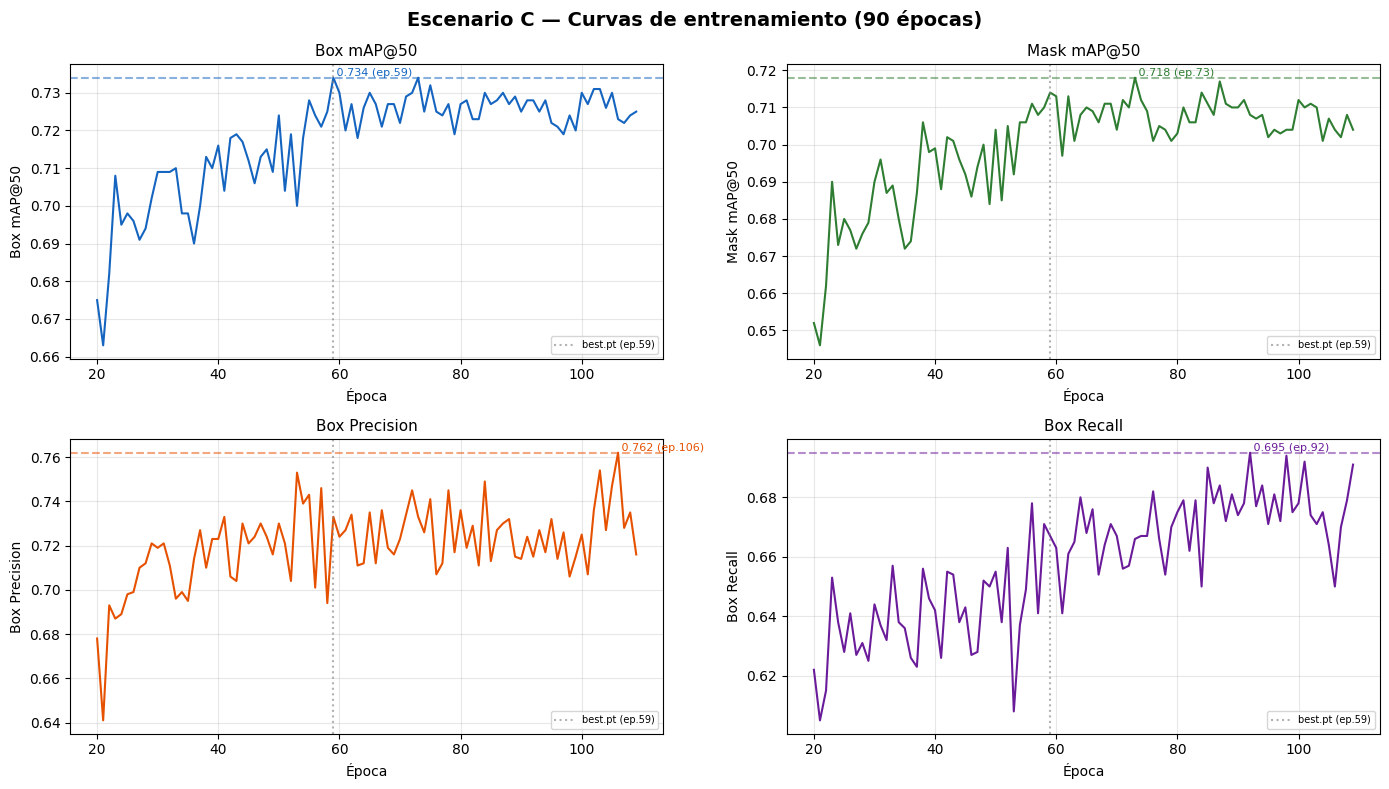


📊 Épocas totales: 90
   Mejor Box mAP@50 : 0.7340  (época 59)
   Mejor Mask mAP@50: 0.7180  (época 73)
   Figura guardada  : /content/drive/MyDrive/PotatoWeed/runs/escenario_C_completo/curvas_entrenamiento_C.png


In [ ]:
# Celda 8 · Curvas de entrenamiento — versión definitiva
# Lee results.csv completo (90 épocas, extraído del log del notebook).

import pandas as pd
import matplotlib.pyplot as plt
import shutil
from pathlib import Path

try:
    _ = RUNS_DRIVE, RUN_NAME_C
except NameError:
    print('⚠️  Ejecuta la Celda 3 primero.')
    raise

csv_drive = Path(f'{RUNS_DRIVE}/{RUN_NAME_C}/results.csv')

if not csv_drive.exists():
    print(f'❌ No se encontró: {csv_drive}')
    print('   Sube el archivo results_escenario_C.csv a esa ruta en Drive.')
else:
    print(f'✅ Leyendo: {csv_drive}')
    df = pd.read_csv(csv_drive)
    df.columns = df.columns.str.strip()
    print(f'   Épocas: {len(df)}  ({int(df["epoch"].min())}–{int(df["epoch"].max())})')

    BEST_EP    = 59
    BEST_MAP50 = 0.734

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle('Escenario C — Curvas de entrenamiento (90 épocas)', fontsize=14, fontweight='bold')

    metricas = [
        ('metrics/mAP50(B)',     'Box mAP@50',    axes[0,0], '#1565C0'),
        ('metrics/mAP50(M)',     'Mask mAP@50',   axes[0,1], '#2E7D32'),
        ('metrics/precision(B)', 'Box Precision', axes[1,0], '#E65100'),
        ('metrics/recall(B)',    'Box Recall',    axes[1,1], '#6A1B9A'),
    ]

    for col, titulo, ax, color in metricas:
        ax.plot(df['epoch'], df[col], color=color, linewidth=1.5)
        ax.set_title(titulo, fontsize=11)
        ax.set_xlabel('Época')
        ax.set_ylabel(titulo)
        ax.grid(True, alpha=0.3)
        best_val = df[col].max()
        best_ep  = int(df.loc[df[col].idxmax(), 'epoch'])
        ax.axhline(best_val, color=color, linestyle='--', alpha=0.5)
        ax.text(best_ep, best_val, f' {best_val:.3f} (ep.{best_ep})',
                fontsize=8, color=color, va='bottom')
        ax.axvline(BEST_EP, color='gray', linestyle=':', alpha=0.6,
                   label=f'best.pt (ep.{BEST_EP})')
        ax.legend(fontsize=7)

    plt.tight_layout()
    out_png = Path(f'{RUNS_DRIVE}/{RUN_NAME_C}/curvas_entrenamiento_C.png')
    plt.savefig(out_png, dpi=130, bbox_inches='tight')
    plt.show()

    print(f'\n📊 Épocas totales: {len(df)}')
    print(f'   Mejor Box mAP@50 : {df["metrics/mAP50(B)"].max():.4f}  (época {int(df.loc[df["metrics/mAP50(B)"].idxmax(), "epoch"])})')
    print(f'   Mejor Mask mAP@50: {df["metrics/mAP50(M)"].max():.4f}  (época {int(df.loc[df["metrics/mAP50(M)"].idxmax(), "epoch"])})')
    print(f'   Figura guardada  : {out_png}')

### Celda 9 · Evaluación en test set + comparativa B vs C vs Paper
Corre `model.val()` sobre el test set con el mejor modelo del Escenario C. Muestra métricas por clase (crop / weed) y las compara directamente con el Escenario B y con los resultados reportados en el paper.

In [16]:
# Celda 9 · Evaluación en test set + comparativa B vs C vs Paper
# Corrige extracción de mAP@50 por clase (usa ap50, no maps)

from ultralytics import YOLO
from pathlib import Path
import math

best_drive = Path(f'{RUNS_DRIVE}/{RUN_NAME_C}/weights/best.pt')
best_local = Path(f'/content/runs/escenario_C_completo/weights/best.pt')
best_path  = best_drive if best_drive.exists() else best_local

if not best_path.exists():
    print('❌ No se encontró best.pt')
else:
    print(f'📂 Usando modelo: {best_path}\n')
    model_C = YOLO(str(best_path))

    metrics = model_C.val(
        data    = YAML_PATH,
        split   = 'test',
        imgsz   = HP['imgsz'],
        batch   = HP['batch'],
        verbose = True,
    )

    # ── Métricas globales ─────────────────────────────────────
    map50_C      = metrics.box.map50
    map5095_C    = metrics.box.map
    prec_C       = metrics.box.mp
    rec_C        = metrics.box.mr
    mask_map50_C = metrics.seg.map50 if hasattr(metrics, 'seg') else float('nan')

    # ── mAP@50 por clase: ap50 (no maps, que es mAP50-95) ────
    ap50 = metrics.box.ap50          # [crop_AP50, weed_AP50]
    crop_map50_C = float(ap50[0]) if len(ap50) >= 2 else float('nan')
    weed_map50_C = float(ap50[1]) if len(ap50) >= 2 else float('nan')

    # ── Precision y Recall por clase ─────────────────────────
    # Extraer desde metrics.box.p y metrics.box.r (arrays por clase)
    try:
        crop_p_C = float(metrics.box.p[0]); crop_r_C = float(metrics.box.r[0])
        weed_p_C = float(metrics.box.p[1]); weed_r_C = float(metrics.box.r[1])
    except Exception:
        crop_p_C = crop_r_C = weed_p_C = weed_r_C = float('nan')

    # ── Valores Escenario B (test=74 imgs) ────────────────────
    B = dict(
        map50=0.693, map5095=0.451, prec=0.708, rec=0.650, mask50=0.667,
        crop_map50=0.886, crop_p=0.844, crop_r=0.856,
        weed_map50=0.499, weed_p=0.571, weed_r=0.444,
    )

    # ── Paper Tabla 2 — After Augmentation, YOLOv8 ───────────
    PAPER = dict(
        map50=0.834, map5095=0.5315, prec=0.821, rec=0.781,
        crop_map50=float('nan'), crop_p=0.898, crop_r=0.910,
        weed_map50=float('nan'), weed_p=0.744, weed_r=0.652,
    )

    def fmt(v): return f'{v:.3f}' if not math.isnan(v) else '  —  '
    def delta(b, c): return f'({c-b:+.3f})' if not (math.isnan(c) or math.isnan(b)) else ''

    print('\n' + '═'*72)
    print('  COMPARATIVA: ESCENARIO B vs C vs PAPER')
    print('  Fuente paper: Goyal et al. 2025, Crop Protection 187, Tabla 2')
    print('═'*72)
    print(f'  {"Métrica":<34} {"Esc.B":>7} {"Esc.C":>7} {"Paper":>7}  {"ΔB→C":>8}')
    print('  ' + '─'*68)

    filas = [
        ('Box mAP@50 — all',         B['map50'],      map50_C,      PAPER['map50']),
        ('Box mAP@50-95 — all',      B['map5095'],    map5095_C,    PAPER['map5095']),
        ('Box Precision — all',      B['prec'],       prec_C,       PAPER['prec']),
        ('Box Recall — all',         B['rec'],        rec_C,        PAPER['rec']),
        ('Mask mAP@50 — all',        B['mask50'],     mask_map50_C, float('nan')),
        ('─'*34,                     None, None, None),
        ('Box mAP@50 — crop',        B['crop_map50'], crop_map50_C, PAPER['crop_map50']),
        ('Box Precision — crop',     B['crop_p'],     crop_p_C,     PAPER['crop_p']),
        ('Box Recall — crop',        B['crop_r'],     crop_r_C,     PAPER['crop_r']),
        ('─'*34,                     None, None, None),
        ('Box mAP@50 — weed',        B['weed_map50'], weed_map50_C, PAPER['weed_map50']),
        ('Box Precision — weed',     B['weed_p'],     weed_p_C,     PAPER['weed_p']),
        ('Box Recall — weed',        B['weed_r'],     weed_r_C,     PAPER['weed_r']),
    ]

    for row in filas:
        nombre, val_b, val_c, val_p = row
        if val_b is None:
            print(f'  {"─"*68}')
            continue
        print(f'  {nombre:<34} {fmt(val_b):>7} {fmt(val_c):>7} {fmt(val_p):>7}  {delta(val_b, val_c):>8}')

    print('═'*72)
    print(f'  Esc.B : 1,172 imgs · 100 épocas · sin aumento · test=74 imgs')
    print(f'  Esc.C : 4,835 imgs · 600 épocas · con aumento  · test=242 imgs')
    print(f'  Paper : mismo dataset/config que Esc.C, evaluado en su propio split')
    print(f'\n  ⚠  B y C usan test sets distintos — comparación indicativa, no directa')
    print('═'*72)

📂 Usando modelo: /content/drive/MyDrive/PotatoWeed/runs/escenario_C_completo/weights/best.pt

Ultralytics 8.4.140 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,258,454 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2200.4±590.9 MB/s, size: 95.0 KB)
val: Scanning /content/yolo_dataset_C/labels/test.cache... 242 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 242/242 72.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 61/61 9.9it/s 6.1s
                   all        242        951      0.721       0.65      0.668       0.41        0.7      0.646      0.641      0.345
                  crop        235        526      0.778      0.833      0.832      0.569      0.754      0.819      0.799      0.498
                  weed        184        425      0.664      0.468      0.50

### Celda 10 · Inferencia sobre 20 imágenes Sony
Corre el modelo C sobre las mismas 20 imágenes Sony originales (sin label) que se usaron en el Escenario B con la misma semilla aleatoria (seed=42). Permite comparar visualmente cuántas malezas detecta ahora el modelo mejorado.

In [ ]:
from ultralytics import YOLO
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon
from PIL import Image
import numpy as np
import random

SONY_BASE = '/content/drive/MyDrive/PotatoWeed/dataset'
SONY_DIRS = {
    'train_weed': Path(f'{SONY_BASE}/Train/Train/weed'),
    'train_crop': Path(f'{SONY_BASE}/Train/Train/crop'),
    'test_weed':  Path(f'{SONY_BASE}/Test/Test/weed'),
    'test_crop':  Path(f'{SONY_BASE}/Test/Test/crop'),
}

# ── Localizar modelo C ────────────────────────────────────────
best_local = Path(f'{RUNS_LOCAL}/segment/{RUN_NAME_C}/weights/best.pt')
best_drive = Path(f'{RUNS_DRIVE}/{RUN_NAME_C}/weights/best.pt')
best_path  = best_local if best_local.exists() else best_drive

if not best_path.exists():
    print('❌ No se encontró best.pt — ejecuta la Celda 7 primero')
else:
    model_C = YOLO(str(best_path))
    print('✅ Modelo C cargado')

    # ── Recolectar imágenes Sony ──────────────────────────────
    sony_imgs = []
    for grupo, carpeta in SONY_DIRS.items():
        imgs = [str(p) for p in carpeta.glob('resized_DSC*')]
        sony_imgs.extend(imgs)
    print(f'   Total Sony disponibles: {len(sony_imgs)}')

    # Misma seed que Escenario B → mismas 20 imágenes → comparación válida
    random.seed(42)
    muestra = random.sample(sony_imgs, 20)

    print('\n⏳ Corriendo inferencia...')
    resultados = model_C.predict(
        source  = muestra,
        imgsz   = HP['imgsz'],
        conf    = 0.25,
        verbose = False,
        save    = False,
    )
    print('✅ Inferencia completada')

    # ── Visualización 5×4 ─────────────────────────────────────
    COLOR_CROP = np.array([33, 150, 243]) / 255
    COLOR_WEED = np.array([255, 87, 34])  / 255

    fig, axes = plt.subplots(5, 4, figsize=(20, 22))
    fig.suptitle(
        'Inferencia Escenario C — 20 Sony originales (sin label)\n'
        '■ Azul = crop   ■ Naranja = weed   conf ≥ 0.25',
        fontsize=14, fontweight='bold'
    )

    for ax, (r, img_path) in zip(axes.flat, zip(resultados, muestra)):
        img = np.array(Image.open(img_path).convert('RGB'))
        ax.imshow(img)
        n_crop = n_weed = 0
        if r.masks is not None:
            for j, mask_xy in enumerate(r.masks.xy):
                cls   = int(r.boxes.cls[j].item())
                conf  = float(r.boxes.conf[j].item())
                color = COLOR_CROP if cls == 0 else COLOR_WEED
                if cls == 0: n_crop += 1
                else:        n_weed += 1
                if len(mask_xy) >= 3:
                    poly = Polygon(mask_xy, closed=True, linewidth=1.2,
                                   edgecolor=color, facecolor=(*color, 0.25))
                    ax.add_patch(poly)
                cx = mask_xy[:, 0].mean()
                cy = mask_xy[:, 1].mean()
                ax.text(cx, cy, f'{conf:.2f}', color='white', fontsize=6,
                        fontweight='bold', ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.1', facecolor=color,
                                  alpha=0.7, linewidth=0))
        nombre = Path(img_path).stem[:18]
        ax.set_title(f'crop:{n_crop}  weed:{n_weed}\n{nombre}', fontsize=7.5, pad=3)
        ax.axis('off')

    patch_c = mpatches.Patch(color=COLOR_CROP, alpha=0.7, label='crop')
    patch_w = mpatches.Patch(color=COLOR_WEED, alpha=0.7, label='weed')
    fig.legend(handles=[patch_c, patch_w], loc='lower center',
               ncol=2, fontsize=12, frameon=False, bbox_to_anchor=(0.5, 0.01))
    plt.tight_layout()
    out_png = f'{RUNS_DRIVE}/{RUN_NAME_C}/inferencia_sony_C_20.png'
    plt.savefig(out_png, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'✅ Figura guardada: {out_png}')

    # ── Resumen numérico ──────────────────────────────────────
    print('\n📊 RESUMEN INFERENCIA ESCENARIO C (20 imágenes Sony):')
    print('─' * 50)
    print(f'  {"":<25} {"Esc.B":>8} {"Esc.C":>8}')
    print('  ' + '─'*44)

    total_crop = total_weed = 0
    confs_crop, confs_weed = [], []
    for r in resultados:
        if r.boxes:
            for cls, conf in zip(r.boxes.cls, r.boxes.conf):
                if int(cls) == 0:
                    total_crop += 1
                    confs_crop.append(float(conf))
                else:
                    total_weed += 1
                    confs_weed.append(float(conf))

    print(f'  {"Media crop/img":<25} {3.9:>8.1f} {total_crop/20:>8.1f}')
    print(f'  {"Media weed/img":<25} {0.7:>8.1f} {total_weed/20:>8.1f}')
    if confs_crop:
        print(f'  {"Conf media crop":<25} {"—":>8} {np.mean(confs_crop):>8.2f}')
    if confs_weed:
        print(f'  {"Conf media weed":<25} {"—":>8} {np.mean(confs_weed):>8.2f}')
    print('─' * 50)

Output hidden; open in https://colab.research.google.com to view.

### Celda 11 · Análisis de errores — peor recall de weed
Identifica las imágenes del test set donde el modelo falla más en detectar malezas: cuenta falsos negativos (weeds en el label que el modelo no detectó) y los visualiza. Útil para entender qué casos específicos siguen siendo difíciles después del Escenario C.

In [ ]:
from ultralytics import YOLO
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon
from PIL import Image
import numpy as np

# ── Localizar modelo C ────────────────────────────────────────
best_local = Path(f'{RUNS_LOCAL}/segment/{RUN_NAME_C}/weights/best.pt')
best_drive = Path(f'{RUNS_DRIVE}/{RUN_NAME_C}/weights/best.pt')
best_path  = best_local if best_local.exists() else best_drive

if not best_path.exists():
    print('❌ No se encontró best.pt')
else:
    model_C = YOLO(str(best_path))

    # ── Recolectar imágenes del test set ──────────────────────
    test_imgs  = sorted(Path(f'{CONTENT_DS}/images/test').glob('*.jpg'))
    test_labels_dir = Path(f'{CONTENT_DS}/labels/test')
    print(f'   Test set: {len(test_imgs)} imágenes')

    # ── Inferencia sobre test completo (baja conf para capturar más) ──
    print('⏳ Inferencia sobre test set...')
    resultados = model_C.predict(
        source  = [str(p) for p in test_imgs],
        imgsz   = HP['imgsz'],
        conf    = 0.20,
        verbose = False,
        save    = False,
    )
    print(f'✅ Inferencia completada ({len(resultados)} imágenes)')

    # ── Calcular falsos negativos por imagen ──────────────────
    errores = []
    for img_path, r in zip(test_imgs, resultados):
        label_path = test_labels_dir / (img_path.stem + '.txt')
        if not label_path.exists():
            continue
        # Weeds en ground truth
        gt_weeds = sum(1 for l in label_path.read_text().strip().splitlines()
                       if l and int(l.split()[0]) == 1)
        # Weeds detectadas
        det_weeds = 0
        if r.boxes is not None:
            det_weeds = sum(1 for c in r.boxes.cls if int(c) == 1)
        fn = max(0, gt_weeds - det_weeds)
        if gt_weeds > 0:
            errores.append({
                'path': img_path,
                'gt_weeds': gt_weeds,
                'det_weeds': det_weeds,
                'fn': fn,
                'recall_weed': det_weeds / gt_weeds,
                'result': r,
            })

    errores_sorted = sorted(errores, key=lambda x: x['recall_weed'])
    print(f'\n   Imágenes con weeds en GT: {len(errores)}')
    print(f'   Recall weed medio (esta muestra): {np.mean([e["recall_weed"] for e in errores]):.3f}')

    # ── Visualizar top-12 peores ──────────────────────────────
    N = min(12, len(errores_sorted))
    peores = errores_sorted[:N]
    COLOR_WEED = np.array([255, 87, 34]) / 255
    COLOR_CROP = np.array([33, 150, 243]) / 255

    fig, axes = plt.subplots(3, 4, figsize=(20, 14))
    fig.suptitle(
        f'Escenario C — Top {N} imágenes con peor recall de weed\n'
        '■ Azul=crop  ■ Naranja=weed  |  GT=ground truth  DET=detectadas',
        fontsize=13, fontweight='bold'
    )

    for ax, e in zip(axes.flat, peores):
        img = np.array(Image.open(e['path']).convert('RGB'))
        ax.imshow(img)
        r = e['result']
        if r.masks is not None:
            for j, mask_xy in enumerate(r.masks.xy):
                cls   = int(r.boxes.cls[j].item())
                color = COLOR_CROP if cls == 0 else COLOR_WEED
                if len(mask_xy) >= 3:
                    poly = Polygon(mask_xy, closed=True, linewidth=1.5,
                                   edgecolor=color, facecolor=(*color, 0.2))
                    ax.add_patch(poly)
        nombre = e['path'].stem[:20]
        titulo = (f'GT:{e["gt_weeds"]} DET:{e["det_weeds"]} FN:{e["fn"]}\n'
                  f'recall={e["recall_weed"]:.2f} | {nombre}')
        ax.set_title(titulo, fontsize=7, pad=3,
                     color='darkred' if e['recall_weed'] < 0.5 else 'black')
        ax.axis('off')

    # Apagar ejes sobrantes
    for ax in axes.flat[N:]:
        ax.axis('off')

    patch_c = mpatches.Patch(color=COLOR_CROP, alpha=0.7, label='crop det.')
    patch_w = mpatches.Patch(color=COLOR_WEED, alpha=0.7, label='weed det.')
    fig.legend(handles=[patch_c, patch_w], loc='lower center',
               ncol=2, fontsize=11, frameon=False, bbox_to_anchor=(0.5, 0.01))
    plt.tight_layout()
    out_png = f'{RUNS_DRIVE}/{RUN_NAME_C}/analisis_errores_weed_C.png'
    plt.savefig(out_png, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'✅ Figura guardada: {out_png}')

Output hidden; open in https://colab.research.google.com to view.

# Celda 12: inferencia caso Perú

In [5]:
# Celda 10B · Inferencia Perú — con filtro de confianza por clase
# Elimina detecciones duplicadas crop/weed filtrando por umbral mínimo por clase.

from ultralytics import YOLO
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import numpy as np

PERU_DIR = Path('/content/drive/MyDrive/PotatoWeed/peru_imgs')
imgs     = sorted(PERU_DIR.glob('*'))
print(f'📁 Imágenes encontradas: {[p.name for p in imgs]}\n')

# ── Umbrales por clase ────────────────────────────────────────
# CONF_MIN = {0: 0.40, 1: 0.35}   # 0=crop, 1=weed — ajusta si es necesario
CONF_MIN = {0: 0.75, 1: 0.35}   # crop≥0.75  weed≥0.35

# ── Cargar modelo ─────────────────────────────────────────────
best_path = Path(f'{RUNS_DRIVE}/{RUN_NAME_C}/weights/best.pt')
model_C   = YOLO(str(best_path))

# ── Inferencia ────────────────────────────────────────────────
results = model_C.predict(
    source       = str(PERU_DIR),
    imgsz        = HP['imgsz'],
    conf         = 0.25,          # umbral inicial amplio
    agnostic_nms = True,          # NMS cross-class elimina solapamientos
    iou          = 0.4,
    save         = False,
    verbose      = False,
)

# ── Visualizar ────────────────────────────────────────────────
n    = len(results)
cols = min(n, 2)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(8*cols, 6*rows))
axes = np.array(axes).flatten() if n > 1 else [axes]

for ax, r, img_path in zip(axes, results, imgs):
    img = np.array(Image.open(img_path).convert('RGB'))
    ax.imshow(img)

    # ── Filtrar detecciones por umbral por clase ──────────────
    detecciones = []
    if r.boxes is not None:
        for i, box in enumerate(r.boxes):
            cls  = int(box.cls)
            conf = float(box.conf)
            if conf >= CONF_MIN[cls]:
                mask = r.masks.data[i] if r.masks is not None else None
                detecciones.append((cls, conf, box, mask))

    n_crop = sum(1 for cls,_,_,_ in detecciones if cls == 0)
    n_weed = sum(1 for cls,_,_,_ in detecciones if cls == 1)

    # ── Dibujar máscaras y bboxes ────────────────────────────
    for cls, conf, box, mask in detecciones:
        color_mask = [0.1, 0.4, 0.9, 0.45] if cls == 0 else [0.9, 0.4, 0.1, 0.45]
        color_box  = '#1a66ff'              if cls == 0 else '#ff6600'
        label      = 'crop'                 if cls == 0 else 'weed'

        if mask is not None:
            m = mask.cpu().numpy()
            m_r = np.array(Image.fromarray(m).resize(
                (img.shape[1], img.shape[0]), Image.NEAREST))
            overlay = np.zeros((*img.shape[:2], 4))
            overlay[m_r > 0.5] = color_mask
            ax.imshow(overlay)

        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        ax.add_patch(plt.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            fill=False, edgecolor=color_box, linewidth=1.8))
        ax.text(x1, y1-5, f'{label} {conf:.2f}',
                fontsize=8, color=color_box,
                bbox=dict(facecolor='white', alpha=0.65, pad=1, edgecolor='none'))

    ax.set_title(
        f'{img_path.name} | crop:{n_crop}  weed:{n_weed}\n'
        f'(filtro: crop≥{CONF_MIN[0]}  weed≥{CONF_MIN[1]})',
        fontsize=9)
    ax.axis('off')

for ax in axes[n:]:
    ax.axis('off')

patch_c = mpatches.Patch(color='#1a66ff', label='crop')
patch_w = mpatches.Patch(color='#ff6600', label='weed')
fig.legend(handles=[patch_c, patch_w], loc='lower center', ncol=2, fontsize=11)
fig.suptitle('Inferencia Perú — Modelo Escenario C (YOLOv8n-seg)\ncon filtro de confianza por clase',
             fontsize=13, fontweight='bold')
plt.tight_layout()

out_png = Path(f'{RUNS_DRIVE}/{RUN_NAME_C}/inferencia_peru_filtrada.png')
plt.savefig(out_png, dpi=130, bbox_inches='tight')
plt.show()

print(f'\n✅ Figura guardada: {out_png}')
print(f'   Umbrales aplicados: crop≥{CONF_MIN[0]}  weed≥{CONF_MIN[1]}')
print('   Ajusta CONF_MIN si ves falsos positivos o detecciones perdidas.')

Output hidden; open in https://colab.research.google.com to view.